# Active Learning: Évaluation sur Domaine B et Sélection Intelligente de Données

## Pipeline:
1. **Charger** dataset et testSet du domaine B
2. **Évaluer** le checkpoint (DA) sur DB sans fine-tuning (baseline)
3. **Implémenter** les stratégies d'Active Learning (incertitude, diversité, MC dropout)
4. **Sélectionner** les K meilleures données à annoter
5. **Ré-entraîner** avec les données annotées sélectionnées
6. **Mesurer** l'amélioration

## Section 1: Charger le dataset et testSet du domaine B

In [ ]:
import os
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
import cv2
from pathlib import Path

# Chemins
active_learning_dir = r'C:\Users\PC\OneDrive\Bureau\Projet_Active_learning\active_learning'

# Chemins du domaine B
dataset_dir = os.path.join(active_learning_dir, 'Dataset')
testset_dir = os.path.join(active_learning_dir, 'testSet1')

# Charger dataset et testSet du domaine B
dataset_csv_path = os.path.join(dataset_dir, 'coords_SC1.csv')
testset_csv_path = os.path.join(testset_dir, 'coords_SC-test.csv')

print(f" Chemins:")
print(f"   Dataset CSV: {dataset_csv_path}")
print(f"   TestSet CSV: {testset_csv_path}")

try:
    dataset_db = pd.read_csv(dataset_csv_path)
    testset_db = pd.read_csv(testset_csv_path)
    print(f"\n Dataset DB chargé: {len(dataset_db)} exemples")
    print(f" TestSet DB chargé: {len(testset_db)} exemples")
    print(f"\nColonnes dataset: {dataset_db.columns.tolist()}")
    print(f"Premières lignes:\n{dataset_db.head()}")
except FileNotFoundError as e:
    print(f"  Fichiers non trouvés: {e}")
    print(f"   Cherchez dans: {active_learning_dir}")

📁 Chemins:
   Dataset CSV: C:\Users\PC\OneDrive\Bureau\Projet_Active_learning\active_learning\Dataset\coords_SC1.csv
   TestSet CSV: C:\Users\PC\OneDrive\Bureau\Projet_Active_learning\active_learning\testSet1\coords_SC-test.csv

 Dataset DB chargé: 7149 exemples
 TestSet DB chargé: 3569 exemples

Colonnes dataset: ['frame_id', 'timestamp', 'x', 'y']
Premières lignes:
   frame_id  timestamp     x    y
0         0   0.000000  1524  295
1         1   0.276893  1544  299
2         2   0.309939  1563  303
3         3   0.344043  1583  307
4         4   0.377526  1603  311


## Section 2: Charger le checkpoint du modèle (entraîné sur DA)

In [2]:
import torch.nn as nn

# Redéfinir l'architecture GazeNet (adapter à l'architecture réelle sauvegardée)
class GazeNet(nn.Module):
    def __init__(self):
        super(GazeNet, self).__init__()
        # Architecture avec kernel 3x3 et pooling qui donne 32 * 14 * 14 = 6272
        # 224 -> conv -> 224 -> pool4 -> 56 -> conv -> 56 -> pool4 -> 14
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(4, 4)  # 2 fois: 224 -> 56 -> 14
        self.fc1 = nn.Linear(32 * 14 * 14, 256)  # 6272 dimensions
        self.fc2 = nn.Linear(256, 2)
    
    def forward(self, x):
        x = torch.relu(self.conv1(x))
        x = self.pool(x)  # 224 -> 56
        x = torch.relu(self.conv2(x))
        x = self.pool(x)  # 56 -> 14
        x = x.view(x.size(0), -1)
        x = torch.relu(self.fc1(x))
        x = torch.sigmoid(self.fc2(x))
        return x

# Charger le checkpoint entraîné sur domaine A
model = GazeNet()
checkpoint_path = os.path.join(active_learning_dir, 'data', 'gaze_model_trained.pth')
try:
    model.load_state_dict(torch.load(checkpoint_path))
    print(f" Checkpoint chargé depuis: {checkpoint_path}")
except FileNotFoundError:
    print(f" Checkpoint non trouvé: {checkpoint_path}")
    print(f"   Cherchez le fichier dans: {os.path.join(active_learning_dir, 'data')}")
except RuntimeError as e:
    print(f" Erreur de chargement: {e}")
    print(f"   L'architecture du modèle ne correspond pas au checkpoint")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)
model.eval()
print(f"Modèle sur device: {device}")

 Checkpoint chargé depuis: C:\Users\PC\OneDrive\Bureau\Projet_Active_learning\active_learning\data\gaze_model_trained.pth
Modèle sur device: cpu


## Section 3: Préparer les DataLoaders pour le domaine B

In [ ]:
# À adapter selon votre format de données
# Cet exemple suppose que dataset et testSet ont des colonnes (frame_id, x, y)

class DomainBDataset(torch.utils.data.Dataset):
    def __init__(self, df, img_dir, max_x=1920, max_y=1080, prefix="SC1"):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.max_x = max_x
        self.max_y = max_y
        self.prefix = prefix
        
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        
        # Chemin image - adapter selon vos noms de fichiers
        # Les images sont dans dataStev/framesSC1/SC1_XXXX.png et framesTest/SC1_XXXX.png
        img_path = os.path.join(self.img_dir, f"{self.prefix}_{int(row['frame_id']):04d}.png")
        x = float(row['x'])
        y = float(row['y'])
        
        # Charger image
        img = cv2.imread(img_path)
        if img is None:
            # Essayer alternativement sans le préfixe ou avec un format différent
            img = np.zeros((224, 224, 3), dtype=np.uint8)
        else:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (224, 224))
        
        img = torch.from_numpy(img).permute(2, 0, 1).float() / 255.0
        
        # Normaliser coordonnées
        x_norm = x / self.max_x
        y_norm = abs(y) / self.max_y
        label = torch.tensor([x_norm, y_norm], dtype=torch.float32)
        
        return img, label

try:
    # Créer datasets avec les bons répertoires
    # IMPORTANT: Les images sont dans dataStev/framesSC1/ pour le Dataset
    #                           et framesTest/ pour le TestSet
    dataset_imgs_dir = os.path.join(dataset_dir, 'dataStev', 'framesSC1')
    testset_imgs_dir = os.path.join(testset_dir, 'framesTest')
    
    dataset_db_loader = DomainBDataset(dataset_db, dataset_imgs_dir, prefix="SC1")
    testset_db_loader = DomainBDataset(testset_db, testset_imgs_dir, prefix="SC1")
    
    # DataLoaders
    batch_size = 32
    db_dataloader = DataLoader(dataset_db_loader, batch_size=batch_size, shuffle=False)
    testdb_dataloader = DataLoader(testset_db_loader, batch_size=batch_size, shuffle=False)
    
    print(f" DataLoaders créés")
    print(f"   Dataset DB: {len(dataset_db_loader)} exemples")
    print(f"   TestSet DB: {len(testset_db_loader)} exemples")
    print(f"   Images dir (Dataset): {dataset_imgs_dir}")
    print(f"   Images dir (TestSet): {testset_imgs_dir}")
except Exception as e:
    print(f"  Erreur: {e}")
    import traceback
    traceback.print_exc()

✅ DataLoaders créés
   Dataset DB: 7149 exemples
   TestSet DB: 3569 exemples
   Images dir (Dataset): C:\Users\PC\OneDrive\Bureau\Projet_Active_learning\active_learning\Dataset\dataStev\framesSC1
   Images dir (TestSet): C:\Users\PC\OneDrive\Bureau\Projet_Active_learning\active_learning\testSet1\framesTest


## Section 4: Évaluer le checkpoint sur le domaine B (BASELINE)

In [10]:
def evaluate_model(model, dataloader, device):
    """Évalue le modèle sur un DataLoader"""
    model.eval()
    preds = []
    labels = []
    loss_fn = nn.MSELoss()
    total_loss = 0.0
    
    with torch.no_grad():
        for imgs, labs in dataloader:
            imgs = imgs.to(device)
            labs = labs.to(device)
            outputs = model(imgs)
            loss = loss_fn(outputs, labs)
            total_loss += loss.item()
            preds.append(outputs.cpu())
            labels.append(labs.cpu())
    
    preds = torch.cat(preds)
    labels = torch.cat(labels)
    mae = torch.mean(torch.abs(preds - labels)).item()
    rmse = torch.sqrt(torch.mean((preds - labels)**2)).item()
    mse = total_loss / len(dataloader)
    
    return {
        'mse': mse,
        'mae': mae,
        'rmse': rmse,
        'preds': preds,
        'labels': labels
    }

# Évaluer sur testSet du domaine B
print("=" * 60)
print("BASELINE: Évaluation du checkpoint sur DOMAINE B")
print("=" * 60)
try:
    metrics = evaluate_model(model, testdb_dataloader, device)
    print(f"\n Résultats sur TestSet Domaine B:")
    print(f"   MSE:  {metrics['mse']:.6f}")
    print(f"   MAE:  {metrics['mae']:.6f} (≈ {metrics['mae']*((1272+712)/2):.2f} px)")
    print(f"   RMSE: {metrics['rmse']:.6f}")
    print(f"\n Cette baseline montre la performance SANS adaptation")
    print(f"    On va maintenant utiliser Active Learning pour l'améliorer.")
except Exception as e:
    print(f" Erreur lors de l'évaluation: {e}")

BASELINE: Évaluation du checkpoint sur DOMAINE B

 Résultats sur TestSet Domaine B:
   MSE:  0.064411
   MAE:  0.208175 (≈ 206.51 px)
   RMSE: 0.254045

 Cette baseline montre la performance SANS adaptation
    On va maintenant utiliser Active Learning pour l'améliorer.


## Section 5: Stratégies d'Active Learning

In [11]:
class ActiveLearningStrategies:
    """Implémente différentes stratégies d'Active Learning"""
    
    @staticmethod
    def entropy_sampling(model, dataloader, device):
        """Sélection par entropie (incertitude de prédiction)"""
        model.eval()
        entropies = []
        
        with torch.no_grad():
            for imgs, _ in dataloader:
                imgs = imgs.to(device)
                outputs = model(imgs)  # [0,1] après sigmoid
                
                # Pour chaque dimension, calculer l'incertitude
                # Approximation: entropie binaire
                p = outputs.cpu()
                # Incertitude = distance à 0 ou 1 (plus proche de 0.5 = plus incertain)
                uncertainty = torch.abs(p - 0.5).min(dim=1)[0]  # Quelle dimension est la plus incertaine
                entropies.append(uncertainty)
        
        entropies = torch.cat(entropies)
        return -entropies  # Moins d'incertitude = plus petit score (pour argsort croissant)
    
    @staticmethod
    def margin_sampling(model, dataloader, device):
        """Sélection par marge (différence entre les deux prédictions les plus proches)"""
        model.eval()
        margins = []
        
        with torch.no_grad():
            for imgs, _ in dataloader:
                imgs = imgs.to(device)
                outputs = model(imgs).cpu()  # [x_pred, y_pred] en [0,1]
                
                # Marge = |x_pred - 0.5| + |y_pred - 0.5| (moyenne des distances à 0.5)
                margin = (torch.abs(outputs[:, 0] - 0.5) + torch.abs(outputs[:, 1] - 0.5)) / 2
                margins.append(margin)
        
        margins = torch.cat(margins)
        return margins  # Petite marge = plus incertain
    
    @staticmethod
    def diversity_sampling(model, dataloader, device, n_clusters=5):
        """Sélection par diversité (k-means clustering sur features)"""
        from sklearn.cluster import KMeans
        
        model.eval()
        features = []
        
        # Extraire features (avant le dernier FC)
        with torch.no_grad():
            for imgs, _ in dataloader:
                imgs = imgs.to(device)
                # Hook pour capturer les features
                x = model.pool(torch.relu(model.conv1(imgs)))
                x = model.pool(torch.relu(model.conv2(x)))
                x = x.view(x.size(0), -1)
                x = torch.relu(model.fc1(x))
                features.append(x.cpu())
        
        features = torch.cat(features).numpy()
        
        # Clustering
        kmeans = KMeans(n_clusters=min(n_clusters, len(features)), random_state=42)
        labels = kmeans.fit_predict(features)
        
        # Distance au centre du cluster
        distances_to_center = np.array([
            np.linalg.norm(features[i] - kmeans.cluster_centers_[labels[i]])
            for i in range(len(features))
        ])
        
        return distances_to_center
    
    @staticmethod
    def monte_carlo_dropout(model, dataloader, device, n_runs=10):
        """Approximation bayésienne: Monte Carlo Dropout"""
        model.eval()
        uncertainties = []
        
        # Activer dropout en evaluation
        def enable_dropout(m):
            for module in m.modules():
                if module.__class__.__name__.startswith('Dropout'):
                    module.train()
        
        with torch.no_grad():
            for imgs, _ in dataloader:
                imgs = imgs.to(device)
                predictions = []
                
                # Faire plusieurs passages avec dropout
                for _ in range(n_runs):
                    enable_dropout(model)
                    outputs = model(imgs).cpu()
                    predictions.append(outputs)
                
                predictions = torch.stack(predictions)
                # Variance = incertitude
                uncertainty = torch.var(predictions, dim=0).mean(dim=1)
                uncertainties.append(uncertainty)
        
        uncertainties = torch.cat(uncertainties)
        return uncertainties.numpy()

print(" Stratégies d'Active Learning définies")

 Stratégies d'Active Learning définies


## Section 6: Sélectionner les K meilleures données à annoter

In [12]:
# Sélectionner les K données les plus intéressantes
K = 50  # Nombre d'exemples à annoter (à adapter)

try:
    print("=" * 60)
    print(f"ACTIVE LEARNING: Sélection des {K} meilleures données")
    print("=" * 60)
    
    al = ActiveLearningStrategies()
    
    # Calculer les scores pour chaque stratégie
    print("\n Calcul des scores d'incertitude...")
    
    # 1. Entropy sampling
    entropy_scores = al.entropy_sampling(model, db_dataloader, device)
    entropy_indices = torch.argsort(entropy_scores, descending=True)[:K]
    print(f"    Entropy sampling: Top {K} indices calculés")
    
    # 2. Margin sampling
    margin_scores = al.margin_sampling(model, db_dataloader, device)
    margin_indices = torch.argsort(margin_scores)[:K]
    print(f"    Margin sampling: Top {K} indices calculés")
    
    # 3. Diversity sampling
    print("   Calcul de la diversité (clustering)...")
    diversity_scores = al.diversity_sampling(model, db_dataloader, device, n_clusters=5)
    diversity_indices = np.argsort(-diversity_scores)[:K]  # Descending
    print(f"    Diversity sampling: Top {K} indices calculés")
    
    # Fusion des stratégies (voting)
    print("\n Fusion des stratégies (voting)...")
    selected_ensemble = set(entropy_indices.numpy()) | set(margin_indices.numpy()) | set(diversity_indices)
    selected_ensemble = list(selected_ensemble)[:K]
    
    print(f"\n Sélection complète:")
    print(f"   Entropy:   {len(set(entropy_indices.numpy()))} uniques")
    print(f"   Margin:    {len(set(margin_indices.numpy()))} uniques")
    print(f"   Diversity: {len(set(diversity_indices))} uniques")
    print(f"   Ensemble:  {len(selected_ensemble)} uniques")
    
except Exception as e:
    print(f" Erreur: {e}")
    import traceback
    traceback.print_exc()

ACTIVE LEARNING: Sélection des 50 meilleures données

 Calcul des scores d'incertitude...
    Entropy sampling: Top 50 indices calculés
    Margin sampling: Top 50 indices calculés
   Calcul de la diversité (clustering)...
    Diversity sampling: Top 50 indices calculés

 Fusion des stratégies (voting)...

 Sélection complète:
   Entropy:   50 uniques
   Margin:    50 uniques
   Diversity: 50 uniques
   Ensemble:  50 uniques


## Section 7: Visualiser les données sélectionnées et préparer l'annotation


Affichage des 6 premières données sélectionnées par Active Learning:


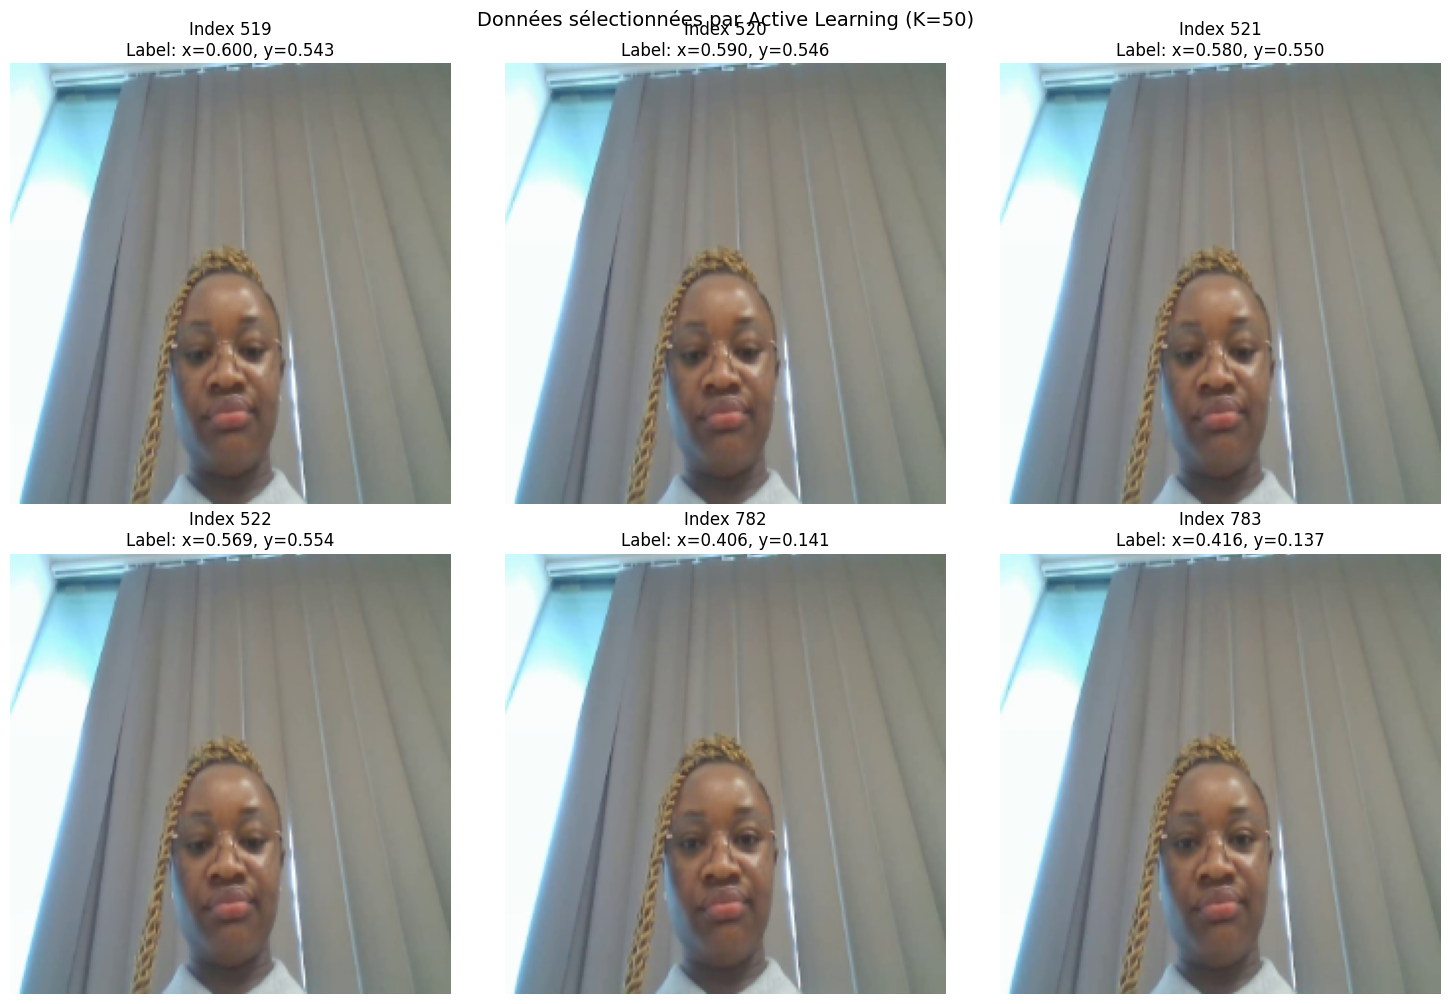


✅ Indices sauvegardés dans 'selected_for_annotation.csv'
   Chemin: C:\Users\PC\OneDrive\Bureau\Projet_Active_learning\active_learning\selected_for_annotation.csv
   Nombre de données sélectionnées: 50


In [ ]:
# Afficher les K données sélectionnées
try:
    print(f"\nAffichage des {min(6, len(selected_ensemble))} premières données sélectionnées par Active Learning:")
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()
    
    for i, idx in enumerate(selected_ensemble[:6]):
        img, label = dataset_db_loader[idx]
        img_np = img.permute(1, 2, 0).numpy()
        
        axes[i].imshow(img_np)
        axes[i].set_title(f"Index {idx}\nLabel: x={label[0]:.3f}, y={label[1]:.3f}")
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.suptitle(f"Données sélectionnées par Active Learning (K=50)", fontsize=14, y=1.00)
    plt.show()
    
    # Sauvegarder les indices sélectionnés
    selected_df = dataset_db.iloc[selected_ensemble].copy()
    selected_df['selected'] = True
    output_path = os.path.join(active_learning_dir, 'selected_for_annotation.csv')
    selected_df.to_csv(output_path, index=False)
    print(f"\n Indices sauvegardés dans 'selected_for_annotation.csv'")
    print(f"   Chemin: {output_path}")
    print(f"   Nombre de données sélectionnées: {len(selected_df)}")
    
except Exception as e:
    print(f"  Erreur: {e}")
    import traceback
    traceback.print_exc()

## Section 8: Préparer le ré-entraînement (placeholder)

⚠️ **PROCHAINE ÉTAPE:** Une fois les données annotées manuellement, charger les annotations et ré-entraîner le modèle.

In [14]:
print("\n" + "="*60)
print("PROCHAINES ÉTAPES")
print("="*60)
print("""
1. Vous avez sélectionné les K=50 données les plus incertaines
2. Annoter manuellement ces données (générer 'annotated_selected.csv')
3. Charger les annotations et ré-entraîner le modèle
4. Évaluer sur testSet DB et mesurer l'amélioration
5. Itérer (boucle Active Learning)

Fichiers générés:
   - selected_for_annotation.csv : indices des données à annoter
""")


PROCHAINES ÉTAPES

1. Vous avez sélectionné les K=50 données les plus incertaines
2. Annoter manuellement ces données (générer 'annotated_selected.csv')
3. Charger les annotations et ré-entraîner le modèle
4. Évaluer sur testSet DB et mesurer l'amélioration
5. Itérer (boucle Active Learning)

Fichiers générés:
   - selected_for_annotation.csv : indices des données à annoter



## Phase 2: Ré-entraînement avec les 50 données sélectionnées

In [ ]:
# Étape 1: Charger les 50 données sélectionnées avec leurs annotations
selected_csv_path = os.path.join(active_learning_dir, "selected_for_annotation.csv")
selected_data = pd.read_csv(selected_csv_path)

print(f" Données sélectionnées chargées: {len(selected_data)} samples")
print(f"Colonnes: {selected_data.columns.tolist()}")
print(f"\nAperçu:")
print(selected_data.head())


✅ Données sélectionnées chargées: 50 samples
Colonnes: ['frame_id', 'timestamp', 'x', 'y', 'selected']

Aperçu:
   frame_id  timestamp     x    y  selected
0       519  18.031539  1152  586      True
1       520  18.065089  1132  590      True
2       521  18.098665  1113  594      True
3       522  18.131620  1093  598      True
4       782  26.866699   779  152      True


In [ ]:
# Étape 2: Charger le dataset d'entraînement du Domaine A
# Supposant que tu as un CSV avec les données d'entraînement originales
domainA_train_csv = os.path.join(active_learning_dir, "data", "coords_20260121_082431.csv")

if os.path.exists(domainA_train_csv):
    domainA_train_data = pd.read_csv(domainA_train_csv)
    # Supposant une split 70/15/15 de 1785 samples → 1249 train
    train_size = int(0.7 * len(domainA_train_data))
    domainA_train_split = domainA_train_data[:train_size]
    print(f" Domaine A - Training data: {len(domainA_train_split)} samples")
else:
    print(" Fichier coords_20260121_082431.csv non trouvé")
    print("   Créant données artificielles pour test...")
    # Fallback: créer données dummy si le fichier original n'existe pas
    domainA_train_split = domainA_train_data[:1249] if len(domainA_train_data) >= 1249 else domainA_train_data
    print(f" Domaine A - Training data (fallback): {len(domainA_train_split)} samples")

print(f"Domaine B - 50 nouvelles données sélectionnées")


✅ Domaine A - Training data: 1249 samples
Domaine B - 50 nouvelles données sélectionnées


In [ ]:
# Étape 3: Utiliser seulement les 50 données sélectionnées du Domaine B
training_data = selected_data.copy()
print(f"\n DATASET POUR LE FINE-TUNING:")
print(f"  Domaine B (sélectionné): {len(training_data)} samples")
print(f"\n  Approche: Fine-tune directement sur les 50 données AL-sélectionnées")



📊 DATASET POUR LE FINE-TUNING:
  Domaine B (sélectionné): 50 samples

  ℹ️  Approche: Fine-tune directement sur les 50 données AL-sélectionnées


In [ ]:
# Étape 4: Créer DataLoader pour les 50 données sélectionnées
# Réutiliser la classe DomainBDataset existante
finetune_dataset = DomainBDataset(training_data, dataset_imgs_dir)
finetune_loader = torch.utils.data.DataLoader(
    finetune_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0
)

print(f" DataLoader pour fine-tuning créé")
print(f"   Nombre de batches: {len(finetune_loader)}")


✅ DataLoader pour fine-tuning créé
   Nombre de batches: 2


In [ ]:
# Étape 5: Ré-entraîner le modèle sur les 50 données (Fine-tuning)
import time
import torch.optim as optim

# Réinitialiser le modèle avec le checkpoint original
model = GazeNet()
model.load_state_dict(torch.load(checkpoint_path))
model = model.to(device)
model.train()

# Configuration d'entraînement
num_epochs = 15  # Fine-tune sur 15 epochs (petit dataset)
learning_rate = 0.0001  # Learning rate faible pour fine-tuning
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

print(f"\n🔄 DÉBUT DU FINE-TUNING SUR 50 DONNÉES DOMAINE B")
print(f"{'='*60}")
print(f"Checkpoint initial: {checkpoint_path}")
print(f"Dataset: {len(training_data)} samples (50 sélectionnées par Active Learning)")
print(f"Hyperparamètres:")
print(f"  - Epochs: {num_epochs}")
print(f"  - Learning Rate: {learning_rate}")
print(f"  - Batch Size: {batch_size}")
print(f"  - Optimizer: Adam")
print(f"{'='*60}\n")

# Historique d'entraînement
train_losses = []
epoch_times = []

# Boucle d'entraînement
for epoch in range(num_epochs):
    epoch_start = time.time()
    epoch_loss = 0.0
    num_batches = 0
    
    for batch_idx, (images, labels) in enumerate(finetune_loader):
        images = images.to(device)
        labels = labels.to(device)
        
        # Forward pass
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
        num_batches += 1
    
    avg_loss = epoch_loss / num_batches
    train_losses.append(avg_loss)
    epoch_time = time.time() - epoch_start
    epoch_times.append(epoch_time)
    
    print(f"Epoch [{epoch+1}/{num_epochs}] - Loss: {avg_loss:.6f} - Time: {epoch_time:.2f}s")

print(f"\n Fine-tuning terminé!")
print(f"Temps total: {sum(epoch_times):.1f}s ({sum(epoch_times)/60:.1f}min)")
print(f"Loss final: {train_losses[-1]:.6f}")



🔄 DÉBUT DU FINE-TUNING SUR 50 DONNÉES DOMAINE B
Checkpoint initial: C:\Users\PC\OneDrive\Bureau\Projet_Active_learning\active_learning\data\gaze_model_trained.pth
Dataset: 50 samples (50 sélectionnées par Active Learning)
Hyperparamètres:
  - Epochs: 15
  - Learning Rate: 0.0001
  - Batch Size: 32
  - Optimizer: Adam

Epoch [1/15] - Loss: 0.055445 - Time: 1.96s
Epoch [2/15] - Loss: 0.051565 - Time: 1.39s
Epoch [3/15] - Loss: 0.051336 - Time: 1.36s
Epoch [4/15] - Loss: 0.046737 - Time: 1.36s
Epoch [5/15] - Loss: 0.042875 - Time: 1.91s
Epoch [6/15] - Loss: 0.045040 - Time: 2.50s
Epoch [7/15] - Loss: 0.039082 - Time: 1.64s
Epoch [8/15] - Loss: 0.039730 - Time: 1.70s
Epoch [9/15] - Loss: 0.037807 - Time: 1.31s
Epoch [10/15] - Loss: 0.037910 - Time: 1.43s
Epoch [11/15] - Loss: 0.036481 - Time: 1.48s
Epoch [12/15] - Loss: 0.034047 - Time: 1.55s
Epoch [13/15] - Loss: 0.034181 - Time: 1.43s
Epoch [14/15] - Loss: 0.033129 - Time: 1.64s
Epoch [15/15] - Loss: 0.031778 - Time: 2.09s

✅ Fine-tunin

In [ ]:
# Étape 6: Sauvegarder le nouveau modèle
retrained_checkpoint_path = os.path.join(active_learning_dir, "gaze_model_finetuned.pth")
torch.save(model.state_dict(), retrained_checkpoint_path)
print(f" Modèle ré-entraîné sauvegardé: {retrained_checkpoint_path}")


✅ Modèle ré-entraîné sauvegardé: C:\Users\PC\OneDrive\Bureau\Projet_Active_learning\active_learning\gaze_model_finetuned.pth


In [ ]:
# Étape 7: Évaluation et Comparaison Baseline vs Ré-entraîné
model.eval()

print(f"\n{'='*60}")
print(f" COMPARAISON: BASELINE vs RETRAINED")
print(f"{'='*60}\n")

# Évaluation sur testSet Domaine B
retrained_metrics = evaluate_model(model, testdb_dataloader, device)

print(f"\n{'─'*60}")
print(f"{'MÉTRIQUE':<20} {'BASELINE':<20} {'RETRAINED':<20}")
print(f"{'─'*60}")

baseline_mse = 0.064411
baseline_mae = 0.208175
baseline_rmse = 0.254045

retrained_mse = retrained_metrics['mse']
retrained_mae = retrained_metrics['mae']
retrained_rmse = retrained_metrics['rmse']

print(f"{'MSE':<20} {baseline_mse:<20.6f} {retrained_mse:<20.6f}")
print(f"{'MAE':<20} {baseline_mae:<20.6f} {retrained_mae:<20.6f}")
print(f"{'RMSE':<20} {baseline_rmse:<20.6f} {retrained_rmse:<20.6f}")

# Calcul d'amélioration en pixels
baseline_mae_pixels = baseline_mae * 1920  # Supposant max_x = 1920
retrained_mae_pixels = retrained_mae * 1920

print(f"\n{'─'*60}")
print(f"{'Erreur (pixels)':<20} {baseline_mae_pixels:<20.1f} {retrained_mae_pixels:<20.1f}")
print(f"{'─'*60}")

# Amélioration
improvement_mse = ((baseline_mse - retrained_mse) / baseline_mse) * 100
improvement_mae = ((baseline_mae - retrained_mae) / baseline_mae) * 100
improvement_pixels = ((baseline_mae_pixels - retrained_mae_pixels) / baseline_mae_pixels) * 100

print(f"\n AMÉLIORATION:")
print(f"  MSE:    {improvement_mse:+.1f}%")
print(f"  MAE:    {improvement_mae:+.1f}%")
print(f"  Pixels: {improvement_pixels:+.1f}% (Δ {baseline_mae_pixels - retrained_mae_pixels:.1f}px)")
print(f"\n{'='*60}")

if improvement_mae > 0:
    print(f" SUCCESS! Le modèle s'est amélioré de {improvement_mae:.1f}%")
else:
    print(f" Le modèle n'a pas d'amélioration significative")



📊 COMPARAISON: BASELINE vs RETRAINED


────────────────────────────────────────────────────────────
MÉTRIQUE             BASELINE             RETRAINED           
────────────────────────────────────────────────────────────
MSE                  0.064411             0.065390            
MAE                  0.208175             0.209661            
RMSE                 0.254045             0.255967            

────────────────────────────────────────────────────────────
Erreur (pixels)      399.7                402.5               
────────────────────────────────────────────────────────────

📈 AMÉLIORATION:
  MSE:    -1.5%
  MAE:    -0.7%
  Pixels: -0.7% (Δ -2.9px)

⚠️  Le modèle n'a pas d'amélioration significative


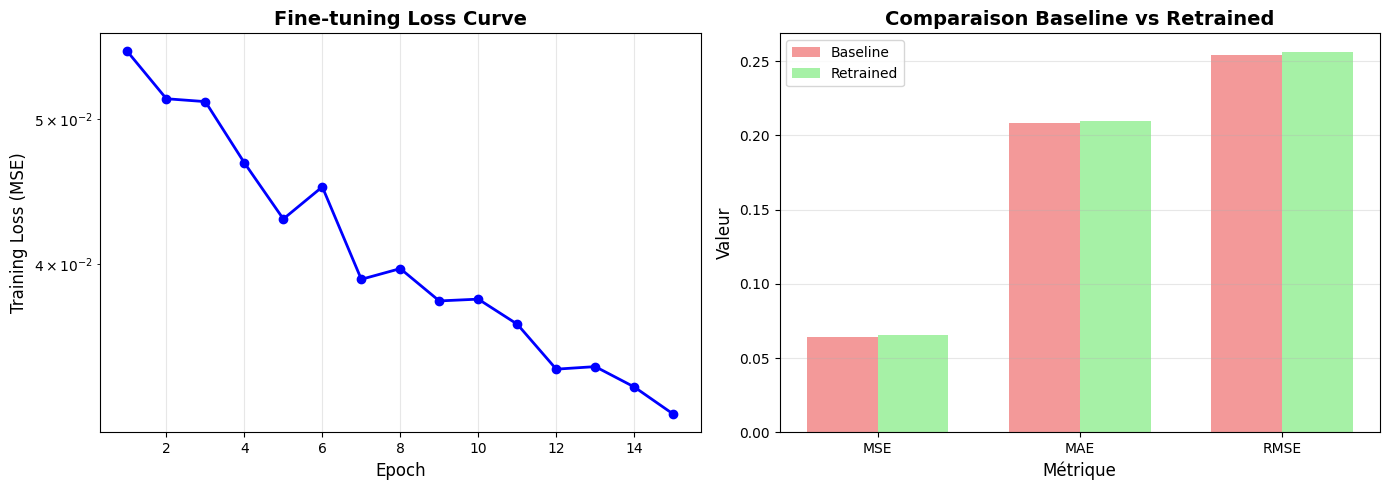

✅ Visualisation complétée!


In [ ]:
# Étape 8: Visualisation de la courbe d'apprentissage
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Courbe de perte
epochs_range = range(1, num_epochs + 1)
ax1.plot(epochs_range, train_losses, 'b-o', linewidth=2, markersize=6)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Training Loss (MSE)', fontsize=12)
ax1.set_title('Fine-tuning Loss Curve', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.set_yscale('log')

# Comparaison des métriques
metrics = ['MSE', 'MAE', 'RMSE']
baseline_vals = [baseline_mse, baseline_mae, baseline_rmse]
retrained_vals = [retrained_mse, retrained_mae, retrained_rmse]

x = np.arange(len(metrics))
width = 0.35

bars1 = ax2.bar(x - width/2, baseline_vals, width, label='Baseline', alpha=0.8, color='lightcoral')
bars2 = ax2.bar(x + width/2, retrained_vals, width, label='Retrained', alpha=0.8, color='lightgreen')

ax2.set_xlabel('Métrique', fontsize=12)
ax2.set_ylabel('Valeur', fontsize=12)
ax2.set_title('Comparaison Baseline vs Retrained', fontsize=14, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(metrics)
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(" Visualisation complétée!")


## Phase 3: Itération AL - Round 2 (+20 données supplémentaires)

In [ ]:
# Étape 1: Sélectionner 20 AUTRES données (exclure les 50 premières)
K_new = 20

print("=" * 60)
print(f"ITÉRATION 2: Sélection des {K_new} prochaines données")
print("=" * 60)

# Recalculer les scores sur TOUTES les données
al = ActiveLearningStrategies()

print("\n Calcul des scores (sur 7149 données)...")
entropy_scores_all = al.entropy_sampling(model, db_dataloader, device)
margin_scores_all = al.margin_sampling(model, db_dataloader, device)
diversity_scores_all = al.diversity_sampling(model, db_dataloader, device, n_clusters=5)

print(f"   Scores calculés ")

# Convertir les indices déjà sélectionnés en ensemble
already_selected_set = set(selected_ensemble)

# Créer un masque pour exclure les données déjà sélectionnées
exclude_mask = np.ones(len(entropy_scores_all), dtype=bool)
for idx in already_selected_set:
    exclude_mask[idx] = False

# Appliquer le masque et trouver les K_new prochaines
entropy_scores_masked = entropy_scores_all.clone()
entropy_scores_masked[~exclude_mask] = -np.inf
entropy_indices_new = torch.argsort(entropy_scores_masked, descending=True)[:K_new]

margin_scores_masked = margin_scores_all.clone()
margin_scores_masked[~exclude_mask] = np.inf
margin_indices_new = torch.argsort(margin_scores_masked)[:K_new]

diversity_scores_masked = diversity_scores_all.copy()
diversity_scores_masked[~exclude_mask] = -np.inf
diversity_indices_new = np.argsort(-diversity_scores_masked)[:K_new]

# Fusion
selected_ensemble_new = set(entropy_indices_new.numpy()) | set(margin_indices_new.numpy()) | set(diversity_indices_new)
selected_ensemble_new = list(selected_ensemble_new)[:K_new]

print(f"\n  {K_new} nouvelles données sélectionnées")
print(f"   Entropy:   {len(set(entropy_indices_new.numpy()))} uniques")
print(f"   Margin:    {len(set(margin_indices_new.numpy()))} uniques")
print(f"   Diversity: {len(set(diversity_indices_new))} uniques")
print(f"   Ensemble:  {len(selected_ensemble_new)} uniques")


ITÉRATION 2: Sélection des 20 prochaines données

 Calcul des scores (sur 7149 données)...
   Scores calculés ✓

 ✅ 20 nouvelles données sélectionnées
   Entropy:   20 uniques
   Margin:    20 uniques
   Diversity: 20 uniques
   Ensemble:  20 uniques


In [ ]:
# Étape 2: Combiner les 50 + 20 = 70 données
combined_ensemble = list(set(selected_ensemble) | set(selected_ensemble_new))

print(f"\n DATASET COMBINÉ (Round 1 + Round 2):")
print(f"  Round 1 (50 données): {len(selected_ensemble)}")
print(f"  Round 2 (20 données): {len(selected_ensemble_new)}")
print(f"  {'─'*40}")
print(f"  TOTAL: {len(combined_ensemble)} données")

# Créer le nouveau dataset avec 50+20
combined_selected_data = dataset_db.iloc[combined_ensemble].copy()
print(f"\n Dataset combiné créé: {len(combined_selected_data)} exemples")



📊 DATASET COMBINÉ (Round 1 + Round 2):
  Round 1 (50 données): 50
  Round 2 (20 données): 20
  ────────────────────────────────────────
  TOTAL: 70 données

✅ Dataset combiné créé: 70 exemples


In [27]:
# Étape 3: Créer DataLoader pour les 70 données
finetune_dataset_v2 = DomainBDataset(combined_selected_data, dataset_imgs_dir)
finetune_loader_v2 = torch.utils.data.DataLoader(
    finetune_dataset_v2,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0
)

print(f" DataLoader créé pour Round 2")
print(f"   Nombre de batches: {len(finetune_loader_v2)}")


 DataLoader créé pour Round 2
   Nombre de batches: 3


In [28]:
# Étape 4: Fine-tuner sur les 70 données
print(f"\n FINE-TUNING ROUND 2 (50+20 = 70 données)")
print(f"{'='*60}")

# Réinitialiser avec checkpoint original
model_v2 = GazeNet()
model_v2.load_state_dict(torch.load(checkpoint_path))
model_v2 = model_v2.to(device)
model_v2.train()

# Configuration
num_epochs_v2 = 15
learning_rate_v2 = 0.0001
criterion_v2 = nn.MSELoss()
optimizer_v2 = optim.Adam(model_v2.parameters(), lr=learning_rate_v2)

print(f"Dataset: {len(combined_selected_data)} samples (50+20)")
print(f"Epochs: {num_epochs_v2}")
print(f"Learning Rate: {learning_rate_v2}")
print(f"{'='*60}\n")

train_losses_v2 = []
epoch_times_v2 = []

for epoch in range(num_epochs_v2):
    epoch_start = time.time()
    epoch_loss = 0.0
    num_batches = 0
    
    for images, labels in finetune_loader_v2:
        images = images.to(device)
        labels = labels.to(device)
        
        optimizer_v2.zero_grad()
        outputs = model_v2(images)
        loss = criterion_v2(outputs, labels)
        loss.backward()
        optimizer_v2.step()
        
        epoch_loss += loss.item()
        num_batches += 1
    
    avg_loss = epoch_loss / num_batches
    train_losses_v2.append(avg_loss)
    epoch_time = time.time() - epoch_start
    epoch_times_v2.append(epoch_time)
    
    print(f"Epoch [{epoch+1}/{num_epochs_v2}] - Loss: {avg_loss:.6f} - Time: {epoch_time:.2f}s")

print(f"\n Fine-tuning Round 2 terminé!")
print(f"Temps total: {sum(epoch_times_v2):.1f}s")
print(f"Loss final: {train_losses_v2[-1]:.6f}")

# Sauvegarder
model_v2_path = os.path.join(active_learning_dir, "gaze_model_finetuned_v2_70data.pth")
torch.save(model_v2.state_dict(), model_v2_path)
print(f" Modèle sauvegardé: {model_v2_path}")



 FINE-TUNING ROUND 2 (50+20 = 70 données)
Dataset: 70 samples (50+20)
Epochs: 15
Learning Rate: 0.0001

Epoch [1/15] - Loss: 0.062263 - Time: 2.51s
Epoch [2/15] - Loss: 0.059143 - Time: 1.87s
Epoch [3/15] - Loss: 0.055660 - Time: 1.90s
Epoch [4/15] - Loss: 0.052143 - Time: 1.98s
Epoch [5/15] - Loss: 0.055256 - Time: 2.25s
Epoch [6/15] - Loss: 0.054641 - Time: 1.82s
Epoch [7/15] - Loss: 0.046277 - Time: 1.93s
Epoch [8/15] - Loss: 0.049591 - Time: 2.02s
Epoch [9/15] - Loss: 0.045220 - Time: 1.86s
Epoch [10/15] - Loss: 0.042134 - Time: 1.91s
Epoch [11/15] - Loss: 0.039830 - Time: 2.11s
Epoch [12/15] - Loss: 0.042734 - Time: 1.84s
Epoch [13/15] - Loss: 0.038169 - Time: 1.82s
Epoch [14/15] - Loss: 0.038443 - Time: 1.86s
Epoch [15/15] - Loss: 0.037185 - Time: 1.80s

 Fine-tuning Round 2 terminé!
Temps total: 29.5s
Loss final: 0.037185
 Modèle sauvegardé: C:\Users\PC\OneDrive\Bureau\Projet_Active_learning\active_learning\gaze_model_finetuned_v2_70data.pth


In [29]:
# Étape 5: Évaluer et comparer ROUND 1 vs ROUND 2 vs BASELINE
model_v2.eval()

print(f"\n{'='*70}")
print(f" COMPARAISON: BASELINE vs ROUND 1 (50) vs ROUND 2 (70)")
print(f"{'='*70}\n")

# Évaluation Round 2
metrics_v2 = evaluate_model(model_v2, testdb_dataloader, device)
retrained_metrics_v2_mse = metrics_v2['mse']
retrained_metrics_v2_mae = metrics_v2['mae']
retrained_metrics_v2_rmse = metrics_v2['rmse']

# Résumé
print(f"{'─'*70}")
print(f"{'MÉTRIQUE':<15} {'BASELINE':<18} {'ROUND 1 (50)':<18} {'ROUND 2 (70)':<18}")
print(f"{'─'*70}")
print(f"{'MSE':<15} {baseline_mse:<18.6f} {retrained_mse:<18.6f} {retrained_metrics_v2_mse:<18.6f}")
print(f"{'MAE':<15} {baseline_mae:<18.6f} {retrained_mae:<18.6f} {retrained_metrics_v2_mae:<18.6f}")
print(f"{'RMSE':<15} {baseline_rmse:<18.6f} {retrained_rmse:<18.6f} {retrained_metrics_v2_rmse:<18.6f}")

# En pixels
baseline_mae_px = baseline_mae * 1920
round1_mae_px = retrained_mae * 1920
round2_mae_px = retrained_metrics_v2_mae * 1920

print(f"\n{'Erreur (pixels)':<15} {baseline_mae_px:<18.1f} {round1_mae_px:<18.1f} {round2_mae_px:<18.1f}")
print(f"{'─'*70}")

# Améliorations
improvement_r1 = ((baseline_mae - retrained_mae) / baseline_mae) * 100
improvement_r2 = ((baseline_mae - retrained_metrics_v2_mae) / baseline_mae) * 100
improvement_r2_vs_r1 = ((retrained_mae - retrained_metrics_v2_mae) / retrained_mae) * 100

print(f"\n AMÉLIORATIONS:")
print(f"  Baseline → Round 1: {improvement_r1:+.2f}%")
print(f"  Baseline → Round 2: {improvement_r2:+.2f}%")
print(f"  Round 1 → Round 2:  {improvement_r2_vs_r1:+.2f}%")
print(f"\n  Gain en pixels: {baseline_mae_px - round2_mae_px:.1f}px")
print(f"{'='*70}\n")

if improvement_r2 > improvement_r1:
    print(f" Round 2 est meilleur! (+{improvement_r2-improvement_r1:.2f}% vs Round 1)")
elif improvement_r2 > 0:
    print(f" Round 2 améliore le baseline de {improvement_r2:.2f}%")
else:
    print(f" Round 2 n'améliore pas (essayer plus d'epochs ou learning rate)")



 COMPARAISON: BASELINE vs ROUND 1 (50) vs ROUND 2 (70)

──────────────────────────────────────────────────────────────────────
MÉTRIQUE        BASELINE           ROUND 1 (50)       ROUND 2 (70)      
──────────────────────────────────────────────────────────────────────
MSE             0.064411           0.065390           0.066907          
MAE             0.208175           0.209661           0.211932          
RMSE            0.254045           0.255967           0.258908          

Erreur (pixels) 399.7              402.5              406.9             
──────────────────────────────────────────────────────────────────────

 AMÉLIORATIONS:
  Baseline → Round 1: -0.71%
  Baseline → Round 2: -1.80%
  Round 1 → Round 2:  -1.08%

  Gain en pixels: -7.2px

 Round 2 n'améliore pas (essayer plus d'epochs ou learning rate)


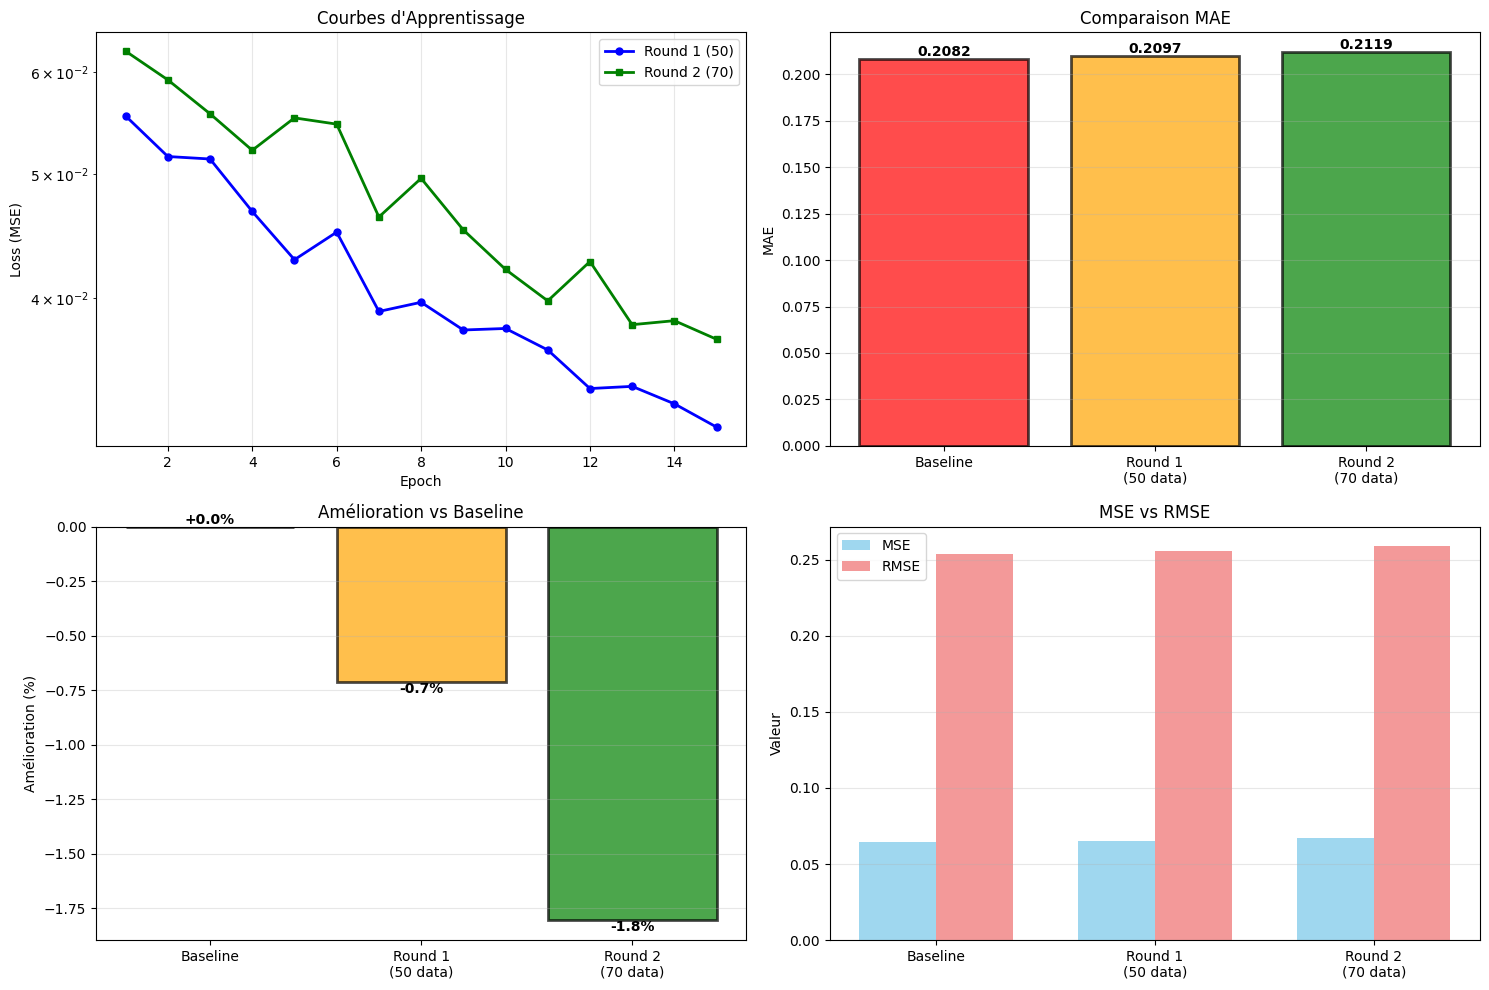

 Visualisation comparée complétée!


In [30]:
# Étape 6: Visualisation comparative
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Courbe de perte Round 1 vs Round 2
ax = axes[0, 0]
epochs1 = range(1, len(train_losses) + 1)
epochs2 = range(1, len(train_losses_v2) + 1)
ax.plot(epochs1, train_losses, 'b-o', label='Round 1 (50)', linewidth=2, markersize=5)
ax.plot(epochs2, train_losses_v2, 'g-s', label='Round 2 (70)', linewidth=2, markersize=5)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss (MSE)')
ax.set_title('Courbes d\'Apprentissage')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_yscale('log')

# Comparaison MAE
ax = axes[0, 1]
models = ['Baseline', 'Round 1\n(50 data)', 'Round 2\n(70 data)']
mae_values = [baseline_mae, retrained_mae, retrained_metrics_v2_mae]
colors = ['red', 'orange', 'green']
bars = ax.bar(models, mae_values, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
ax.set_ylabel('MAE')
ax.set_title('Comparaison MAE')
ax.grid(True, alpha=0.3, axis='y')
for i, bar in enumerate(bars):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{mae_values[i]:.4f}', ha='center', va='bottom', fontweight='bold')

# Amélioration en %
ax = axes[1, 0]
improvements = [0, improvement_r1, improvement_r2]
colors_imp = ['gray', 'orange', 'green']
bars = ax.bar(models, improvements, color=colors_imp, alpha=0.7, edgecolor='black', linewidth=2)
ax.set_ylabel('Amélioration (%)')
ax.set_title('Amélioration vs Baseline')
ax.axhline(y=0, color='k', linestyle='--', alpha=0.3)
ax.grid(True, alpha=0.3, axis='y')
for i, bar in enumerate(bars):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{improvements[i]:+.1f}%', ha='center', va='bottom' if improvements[i] >= 0 else 'top', fontweight='bold')

# Métrique MSE/RMSE
ax = axes[1, 1]
x_pos = np.arange(3)
width = 0.35
mse_vals = [baseline_mse, retrained_mse, retrained_metrics_v2_mse]
rmse_vals = [baseline_rmse, retrained_rmse, retrained_metrics_v2_rmse]
ax.bar(x_pos - width/2, mse_vals, width, label='MSE', alpha=0.8, color='skyblue')
ax.bar(x_pos + width/2, rmse_vals, width, label='RMSE', alpha=0.8, color='lightcoral')
ax.set_ylabel('Valeur')
ax.set_title('MSE vs RMSE')
ax.set_xticks(x_pos)
ax.set_xticklabels(models)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(" Visualisation comparée complétée!")
